# **Equazioni non lineari**

Si consideri il problema della ricerca degli zeri dell'equazione non
lineare $f(x)=0$, dove $f$ è definita da:
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}

# **Rappresentazione grafica della funzione**          
Disegnare il grafico della funzione $f$ e la retta $y=0$ in modo da evidenziare le due soluzioni dell'equazione.

In [2]:
# step 0 -> ricordarsi di importare i pacchetti numpy and matplotlib

import numpy as np
import matplotlib.pyplot as plt

Vediamo un nuovo costrutto utile per costruire funzioni matematiche "lambda function" in modo semplice e veloce.


      f = lambda nome_variabili: espressione della funzione

In [3]:
# esempi di lambda function
def f(x):
    return x**2

print("valuto la funzione f in 0.5: %f" % f(0.5))

#oppure uso le lambda fuction
f=lambda x: x**2
print("valuto la funzione f in 0.5: %f" % f(0.5))

g=lambda t: t**2
print("valuto la funzione g in 0.5: %f" % g(0.5))

h=lambda t, x, y: t+x+y
print("valuto la funzione h in (1,2,3): %f" % h(1, 2, 3))

valuto la funzione f in 0.5: 0.250000
valuto la funzione f in 0.5: 0.250000
valuto la funzione g in 0.5: 0.250000
valuto la funzione h in (1,2,3): 6.000000


Scrivere la funzione $f$ dell'esercizio usando la lambda function

In [4]:
# lambda function della funzione f
f=lambda x: np.exp(x) - x**2 - np.sin(x) - 1


Rappresentazione grafica

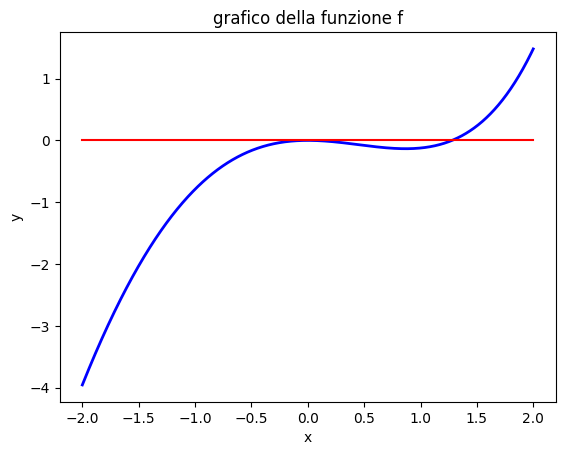

In [5]:
# rappresentazione grafica della funzione f
xgrid=np.linspace(-2,2,1000)
plt.plot(xgrid, f(xgrid), 'b-', linewidth=2)
plt.plot(xgrid, np.zeros(np.shape(xgrid)), 'r') #utile per vedere gli zeri

plt.title('grafico della funzione f')
plt.xlabel("x")
plt.ylabel("y")
plt.show()


# **Bisezione**


<mark>**Domanda:**</mark></br>
 Il metodo di bisezione è applicabile per calcolare
entrambe le radici? Motivare la risposta.



<mark>**Esercizio 1.1: implementazione bisezione**</mark></br>

Scrivere una function $\verb|bisez|$ che implementi il metodo di bisezione. L'intestazione della funzione sarà ad esempio la seguente:


      def bisez(f,a,b,toll):
      #
      # implementazione di bisezione
      #
      return xvect


Tale funzione riceve in input:
* $\verb|f|→$ funzione di cui vogliamo calcolare gli zeri,
* $a→$ primo estremo
* $b→$ secondo estremo
* $\verb|toll|→$ tolleranza richiesta

e in out
* $\verb|xvect|→$ il vettore delle iterate.




In [6]:
# definzione del metodo di bisezione
def bisez(f, a, b, toll):
    if(f(a)*f(b)>=0):
       raise RuntimeError ("Errore: a e b non è una bracket")
    xvect=[] #è una lista vuota
    while(abs(b-a)> toll):
      #calcolo il punto medio
      x=0.5*(a+b)

      if(f(x)==0):
         xvect.append(x)
         print("x è uno zero")
         break 

      if(f(x)*f(a)>0):
         a=x
      else:
         b=x
         
      xvect.append(x)
  
    return np.array(xvect)



<mark>**Esercizio 1.2**</mark></br>
Quando è possibile, applicare il metodo di bisezione alla funzione $f$.
Stampare il numero di iterazioni, lo zero trovato $x^*$ e il valore della funzione $f(x^*)$.

In [8]:
# scelta degli estremi a,b
a,b=1, 1.5
xvect = bisez(f, a , b, 1e-12)

x0=xvect[-1]

#stampare il numero di iterazioni effettuato, il valore di x0 e valore di f(x0)
print("Numero iterazioni: %d" % len(xvect))
print("Ultimo valore di x: %f" % x0)
print("Ultimo valore di f: %.e\n" % f(x0))

Numero iterazioni: 39
Ultimo valore di x: 1.279701
Ultimo valore di f: 7e-13



**Alcuni commenti finali sul metodo di bisezione**

Dalla teoria sappiamo che:

*   Il metodo di bisezione è convergente e abbiamo una stima dell'errore (anche senza dover sapere la soluzione esatta)

\begin{equation}
|e^k| \le \frac{1}{2^{k+1}} |b-a| .
\end{equation}

*   Se voglio ottenere una soluzione esatta a meno di una tolleranza $eps$

\begin{equation}
k > \log_2 \frac{|b-a|}{eps} - 1 .
\end{equation}

*   La convergenza del metodo di bisezione è lenta (l'errore non sempre decresce monotonicamente).

*   Se uno zero ha molteplicità dispari, allora vale il teorema degli zeri. Nel caso di molteplicità pari, non è garantito.

# **Metodo di Newton**

<mark>**Domanda:**</mark></br>
Discutere le proprietà  di convergenza del metodo di Newton per
  entrambi gli zeri, valutando l'opportunità  di applicare il metodo
  di Newton.





<mark>**Esercizio 2.1: implementazione Newton**</mark></br>
Scrivere una function $\verb|newton|$ che implementi il metodo di Newton. L'intestazione della funzione sarà ad esempio la seguente:


      def newton (f,df,x0,nmax,toll)
      #
      # implementazione del metodo di newton
      #
      return xvect

Tale funzione riceve in input:
* $\verb|f|→$ funzione di cui vogliamo calcolare gli zeri,
* $\verb|df|→$ la derivata della funzione $f$,
* $x_0→$ punto di partenza
* $\verb|nmax|→$ numero massimo di iterazione
* $\verb|toll|→$ tolleranza richiesta

e in out
* $\verb|xvect|→$ il vettore delle iterate.

Si utilizzi un criterio d'arresto basato sul modulo della differenza tra due iterate successive.


In [9]:
# definizione del metodo di newton
def newton(f, df, x0, nmax, toll):

  # inizializzazione del vettore delle iterazioni
  xvect=[]
  xold=x0
  
  # ciclo iterativo       
  for nit in range(nmax):
  
    if(df(xold)==0):
      raise RuntimeError ("la derivata prima nel punto xold è uguale a zero")
      
    # passo iterativo
    xnew=xold-f(xold)/df(xold)
      
    # carico i vettori
    xvect.append(xnew) 

    # criterio di arresto e aggiornamento 
    if(abs(xnew-xold)<toll):
      break
    else:
      xold=xnew
  return np.array(xvect)

<mark>**Esercizio 2.2: modifica di Newton**</mark></br>
Si scriva, modificando opportunamente la function $\verb|newton|$,
il metodo di Newton modificato, passando come parametro in ingresso anche la molteplicità dello zero cercato. L'intestazione della funzione sarà la seguente:


      def newton (f,df,x0,nmax,toll,m=1)
        #
        # modificare il passo iteratativo di newton
        #  x^{k+1} = x^k - m f(x^k)/f'(x^k)
        #
        return xvect

dove $\verb|m|$ è la molteplicità dello zero cercato.


In [20]:
def newton (f, df, x0, nmax, toll, m=1):
    xvect=[]
    xold=x0
    for nit in range(nmax):
        if(df(xold)==0):
            raise RuntimeError ("la derivata prima nel punto xold è uguale a zero")
        xnew=xold-m*f(xold)/df(xold)
        xvect.append(xnew)
        if(abs(xnew-xold)<toll):
            break
        else:
            xold=xnew
    return np.array(xvect)

<mark>**Esercizio 2.3**</mark></br>

Applicare il metodo di Newton e, quando è il caso, il metodo di Newton modificato (aggiungendo la specifica $\verb|m|$) con tolleranza $10^{-6}$, per la funzione
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}
Riportare su un grafico in scala semilogaritmica l'andamento dell'errore in funzione del numero di iterazioni. Per il calcolo dell'errore si assuma come valore esatto dello zero non nullo, il valore $x=1.279701331000996$. Cosa si osserva nell'ordine di convergenza?


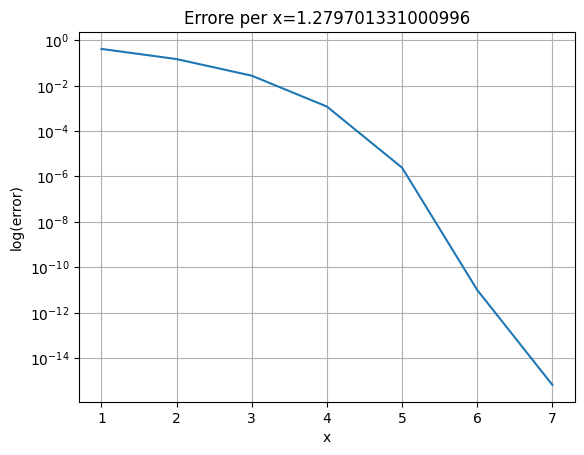

In [21]:
# funzione f e la sua derivata df
f = lambda x: np.exp(x) - x**2 - np.sin(x) - 1.0
df = lambda x: np.exp(x) - 2*x - np.cos(x)
# ricerca dello zero xe=1.279701331000996
xe=1.279701331000996
# starting point
x0=1

xvect=newton(f, df, x0, 100, 1e-6)
    
# calcolo dell'errore
error=np.abs(xe-xvect)

# rappresentazione grafica dell'errore usando plt.semilogy()

plt.semilogy(np.arange(1, len(xvect)+1), error)
plt.title("Errore per x=%.15f" % xe)
plt.xlabel('x')
plt.ylabel('log(error)')
plt.grid()
plt.show()


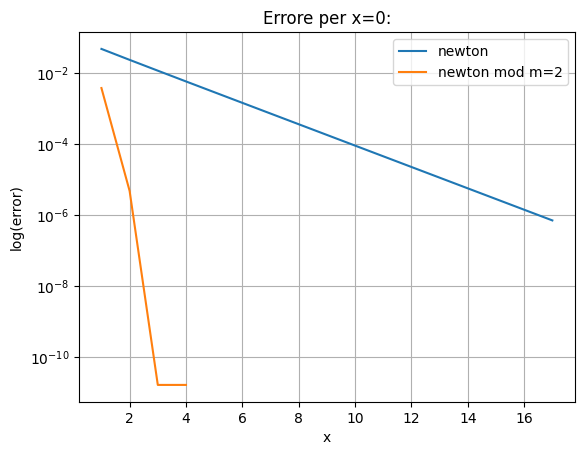

In [22]:
# Ricerca dello zero xe=0
xe=0
# starting point
x0=0.1

xvect_n=newton(f, df, x0, 100, 1e-6)
error_n=np.abs(xe - xvect_n)

#newton modificato con m=2
xvect_nm=newton(f, df, x0, 100, 1e-6, m=2)
error_nm=np.abs(xe-xvect_nm)

plt.semilogy(np.arange(1, len(xvect_n)+1), error_n)
plt.semilogy(np.arange(1, len(xvect_nm)+1), error_nm)
plt.legend(['newton', 'newton mod m=2'])
plt.title("Errore per x=%d:" % xe)
plt.xlabel('x')
plt.ylabel('log(error)')
plt.grid()
plt.show()



**Alcuni commenti finali sul metodo di Newton**

Dalla teoria sappiamo che:

*   Il metodo di Newton è (SOLO) localmente convergente
*   Se converge, allora converge quadraticamente per zeri di molteplicità 1, linearmente per zeri di molteplicità superiore (in tal caso occorre Newton modificato per ripristinare convergenza ottimale)
*   Il metodo di Newton è un particolare metodo di punto fisso

# **Esercizi per casa**


## **Metodo punto fisso**

Si consideri il problema della ricerca degli zeri dell'equazione non lineare $g(x)=0$, dove $g$ è definita da:
\begin{equation}
g(x):= 4x-e^{x^2},\qquad x\in\left[0,\frac{3}{2}\right]\;.
\end{equation}


<mark>**Esercizio 3.1**</mark></br>
Disegnare il grafico della funzione $g$ e la retta $y=0$ in modo
da evidenziare le due soluzioni dell'equazione. Inoltre, per ogni soluzione, determinare un opportuno intervallo che la contenga.

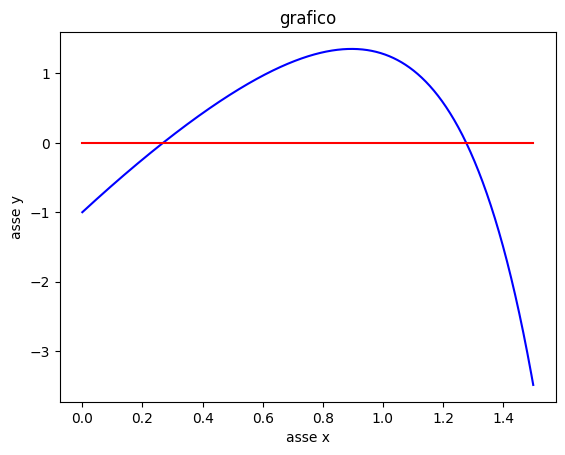

In [23]:
# plot della funzione g

def f(xgrid):
    return 4*xgrid-np.exp(xgrid**2)

xgrid=np.linspace(0, 1.5 , 1000)
plt.plot(xgrid,f(xgrid), 'b')
plt.plot([0,1.5], [0,0], 'r')
plt.title('grafico')
plt.xlabel('asse x')
plt.ylabel('asse y')
plt.show()


**Osservazione sulle soluzioni dell'esercizio 3.1:**

dal grafico si può osservare che ci sono due soluzioni: la prima contenuta nell'intervallo [0.2, 0.4], la seconda nell'intervallo [1.2,1.4]

<mark>**Esercizio 3.2**</mark></br>
Individuare la funzione di iterazione $\phi$ per il metodo di punto fisso e la sua derivata $\phi'(x)$. Plottare $\phi'$ nell'intervallo considerato. Il metodo di punto fisso è applicabile per calcolare
entrambe le radici? Motivare la risposta.

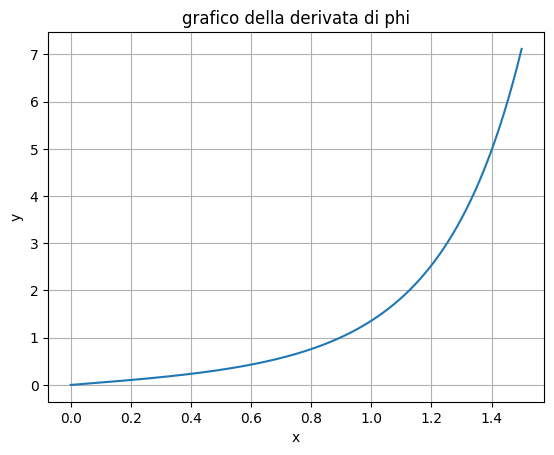

In [24]:
# plot della derivata prima di phi
def phi(t):
    return np.exp(t**2)/4
def dphi(t):
    return t*np.exp(t**2)/2

plt.plot(xgrid, dphi(xgrid))
plt.title ('grafico della derivata di phi')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

**Motivazione esercizio 3.2:**

la funzione 𝜙 è continua e derivabile in ogni intorno dei suoi due punti fissi, che coincidono con gli zeri 𝛼1 e 𝛼2 di 𝑔.
Osservando il grafico di 𝜙′ quello che si osserva è per 𝛼1 valogono le ipotesi del teorema di convergenza del metodo di punto fisso e cioè in un intorno 𝐼1 di 𝛼1: |𝜙′(𝑥)| < 1 ∀𝑥 ∈ 𝐼1.
Di conseguenza, esiste 𝛿 > 0 per cui il metodo di punto fisso definito dalla sequenza 𝑥𝑘+1 = 𝜙(𝑥𝑘), 𝑘 ≥ 0, converge a 𝛼1 ∀𝑥0 tale che |𝑥0 − 𝛼1| < 𝛿.
Invece, in ogni intorno 𝐼2 di 𝛼2 esiste un punto 𝑥̄ tale che |𝜙′(𝑥)̄ | ≥ 1. Di conseguenza il metodo di
punto fisso potrebbe non convergere ad 𝛼2.

<mark>**Esercizio 3.3**</mark></br>

Scrivere la function $\verb|puntofisso|$ che implementi il metodo di punto fisso. L'intestazione della funzione sarà ad esempio la seguente:


      def puntofisso (phi,x0,nmax,toll)
        #
        # implementazione del metodo di newton
        #
        return xvect

Tale funzione riceve in input:
* $\verb|phi|→$ funzione di iterazione,
* $x_0→$ punto di partenza
* $\verb|nmax|→$ numero massimo di iterazione
* $\verb|toll|→$ tolleranza richiesta

e in out
* $\verb|xvect|→$ il vettore delle iterate.

Si utilizzi un criterio d'arresto basato sul modulo della differenza tra due iterate successive.

In [25]:
def puntofisso(phi, x0, nmax, toll):
  xvect=[]
  xold=x0

  for nit in range(nmax):
    xnew=phi(xold) 
    xvect.append(xnew)

    if (abs(xold-xnew)<toll):
      break
    else:
      xold=xnew
  return xvect

<mark>**Esercizio 3.3**</mark></br>
Applicare il metodo del punto fisso, quando possibile, con numero massimo di iterazioni $\verb|nmax|=100$ e tolleranza pari a
$10^{-5}$, utilizzando la funzione $\verb|puntofisso|$ e dati iniziali $x0=0$, $x0=1.5$.

In [26]:
# verifica del metodo di punto fisso
nmax=100
toll=1e-5

for x0 in [0, 1.5]:
    xvect=puntofisso(phi, x0, nmax, toll)
    print("dato iniziale: %f" % x0)
    print("numero di iterazione %d" %len(xvect))
    print("radice trovata: %f" %xvect[-1])




dato iniziale: 0.000000
numero di iterazione 6
radice trovata: 0.268719
dato iniziale: 1.500000
numero di iterazione 100
radice trovata: inf


C:\Users\aless\AppData\Local\Temp\ipykernel_15920\1232355898.py:3: RuntimeWarning: overflow encountered in exp
  return np.exp(t**2)/4
C:\Users\aless\AppData\Local\Temp\ipykernel_15920\3083792732.py:9: RuntimeWarning: invalid value encountered in scalar subtract
  if (abs(xold-xnew)<toll):


## **Bisezione**

<mark>**Esercizio 4.1**</mark></br>
Si consideri il problema della ricerca degli zeri dell'equazione non
lineare $f(x)=0$, dove $f$ è definita da:
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}

Provare ad implementare bisezione con il ciclo for. Ricordo che il numero massimo di iterazioni è
\begin{equation}
 k > \log_2(\frac{|b-a|}{\text{toll}}) -1
\end{equation}
con $k$ un numero intero. Ricordo che nel caso in cui si ottenga un numero non intero nell'espressione a destra allora $k$ va arrotondato al numero intero superiore. Un comando utile per il calcolo di $k$ è $\verb|np.fix|$ (si veda $\verb|help(np.fix)|$).



In [29]:
def bisezfor(f, a, b, toll):
  if (f(a)*f(b)>=0):
    raise RuntimeError('l intervallo [a, b] non è un bracket')  

  nmax=np.fix(np.log2(abs(b-a)/toll)-1)
  xvect=[]

  for i in range (int(nmax)):
    x=(b-a)/2
    if (f(x)==0):
      xvect.append(x)
      break
    if(f(a)*f(x)>0):
      a=x
    else: 
      b=x
    xvect.append(x)

  return np.array(xvect)


In [28]:
help(np.fix)

Help on method descriptor fix in module numpy:

fix(x, out=None)
    Round to nearest integer towards zero.

    Round an array of floats element-wise to nearest integer towards zero.
    The rounded values have the same data-type as the input.

    Parameters
    ----------
    x : array_like
        An array to be rounded
    out : ndarray, optional
        A location into which the result is stored. If provided, it must have
        a shape that the input broadcasts to. If not provided or None, a
        freshly-allocated array is returned.

    Returns
    -------
    out : ndarray of floats
        An array with the same dimensions and data-type as the input.
        If second argument is not supplied then a new array is returned
        with the rounded values.

        If a second argument is supplied the result is stored there.
        The return value ``out`` is then a reference to that array.

    See Also
    --------
    rint, trunc, floor, ceil
    around : Round to given 

<mark>**Esercizio 4.2**</mark></br>
Testare la function $\verb|bisezfor|$ nella ricerca degli zeri della funzione $f$.

In [30]:
f = lambda x: np.exp(x) - x**2 - np.sin(x) - 1.0
# scelta degli estremi a,b
a, b= 1, 2
xvect=bisezfor(f, a, b, 1e-12)

# stampare iterazioni, valore di x* e valore di f(x*)
xfin=xvect[-1]
print ('il numero di iterazioni è %d' %len(xvect))
print('lo zero è %f' %xfin)
print ('il valore della funzione nello zero è %f' %f(xfin))

il numero di iterazioni è 38
lo zero è 0.666667
il valore della funzione nello zero è -0.115080


## **Bisezione e Newton**
<mark>**Esercizio 5**</mark></br>
Si consideri il problema della ricerca degli zeri dell'equazione non
lineare $f(x)=0$, dove $f$ è definita da:
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}
Utilizzare in sequenza il metodo di bisezione e il metodo di Newton per la ricerca dello zero $1 < \alpha_2 < 1.5$; in particolare si adotti il metodo di bisezione per l'avvicinamento allo zero e successivamente il metodo di Newton per la
convergenza "veloce" ad $\alpha_2$, assumendo come punto di innesco lo zero approssimato con il metodo di bisezione. Nello specifico si considerino 5 iterazioni del metodo di bisezione sull'intervallo $[1, 1.5]$ e si assuma come tolleranza per il metodo di Newton il valore $10^{-10}$.



In [35]:
# estremi dell'intervallo
a=1
b=1.5
f = lambda x: np.exp(x) - x**2 - np.sin(x) - 1.0
df = lambda x: np.exp(x) - 2*x - np.cos(x)

nmax_b=5 #è il nostro k da cui ricaviamo la tolleranza
toll_b=1.e-3
nmax_n=100
toll_n=1e-10

xvect_b=bisez(f,a,b,toll_b)
x0_n=xvect_b[-1]
xvect_n=newton(f, df, x0_n, nmax_n, toll_n)
xvect=np.concatenate([xvect_b[0: nmax], xvect_n])
x=xvect[-1]
print("Numero iterazioni: %d." % len(xvect))
print("Ultimo valore di x: %1.10f" % x)
print("Ultimo valore di f: %.e" % f(x))



Numero iterazioni: 12.
Ultimo valore di x: 1.2797013310
Ultimo valore di f: 4e-16
